# mlAgent Run Comparison

Compare selected runs across different strategies/architectures. Understand score progression, cost efficiency, and the experiment process.

In [49]:
# ====== CONFIG: edit these to select runs ======

# Option 1: Specify run folder paths directly (takes priority if non-empty)
# RUN_PATHS = [
#     "workspace/pack_20260324_173330/run_20260324_152740_board_spooky-author-identification",
#     "workspace/pack_20260324_173330/run_20260324_152636_spooky-author-identification",
# ]
# RUN_PATHS = [
#     "workspace/pack_20260325_213400/run_20260325_182052_spooky-author-identification",
#     "workspace/pack_20260325_213400/run_20260325_182132_board_spooky-author-identification",
#     "workspace/pack_20260325_213400/run_20260325_182151_todo_spooky-author-identification",
# ]
RUN_PATHS = [
    "workspace/pack_20260326_133232/run_20260325_220749_board_random-acts-of-pizza",
    "workspace/pack_20260326_133232/run_20260325_220749_random-acts-of-pizza",
]

# Option 2: Auto-discover runs from workspace, with optional filters
WORKSPACE = "workspace"        # root folder containing packs
FILTER_COMPETITION = ""        # e.g. "spooky-author-identification" (empty = all)
FILTER_TIME_AFTER = ""         # e.g. "20260324_150000" (empty = all)
FILTER_TIME_BEFORE = ""        # e.g. "20260324_180000" (empty = all)
FILTER_STRATEGY = ""           # e.g. "board" or "todo" or "" for all

# Display
LOWER_IS_BETTER = True         # set False if your metric is accuracy-like

In [50]:
import json, re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

# ---- Discover runs ----
def parse_run_dir(name):
    """Extract timestamp and competition from run folder name like run_20260324_152740_board_spooky-author-identification"""
    m = re.match(r"run_(\d{8}_\d{6})_(?:(board|todo)_)?(.*)", name)
    if not m:
        return None
    return {"time": m.group(1), "strategy_tag": m.group(2) or "baseline", "competition": m.group(3)}

def discover_runs(workspace):
    found = []
    ws = Path(workspace)
    for pack_dir in sorted(ws.iterdir()):
        if not pack_dir.is_dir() or pack_dir.name.endswith(".tgz"):
            continue
        for run_dir in sorted(pack_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if (run_dir / "experiment_log.json").exists():
                found.append(run_dir)
    return found

def load_run(run_path):
    run_path = Path(run_path)
    info = parse_run_dir(run_path.name) or {"time": "?", "strategy_tag": "?", "competition": "?"}
    with open(run_path / "experiment_log.json") as f:
        log = json.load(f)
    run = {"path": run_path, "log": log, **info}
    for extra in ["experiment_board.json", "experiment_map.json", "todo_list.json"]:
        p = run_path / extra
        if p.exists():
            with open(p) as f:
                run[extra.replace(".json", "")] = json.load(f)
    return run

# ---- Build run list ----
if RUN_PATHS:
    run_dirs = [Path(p) for p in RUN_PATHS]
else:
    run_dirs = discover_runs(WORKSPACE)

runs = []
for rd in run_dirs:
    r = load_run(rd)
    # Apply filters
    if FILTER_COMPETITION and FILTER_COMPETITION not in r["competition"]:
        continue
    if FILTER_TIME_AFTER and r["time"] < FILTER_TIME_AFTER:
        continue
    if FILTER_TIME_BEFORE and r["time"] > FILTER_TIME_BEFORE:
        continue
    if FILTER_STRATEGY and FILTER_STRATEGY not in r["strategy_tag"]:
        continue
    runs.append(r)

# Generate short labels
for r in runs:
    r["label"] = f"{r['strategy_tag']}_{r['time']}"

palette = sns.color_palette("tab10", max(len(runs), 1))
for i, r in enumerate(runs):
    r["color"] = palette[i]

cum_fn = np.minimum.accumulate if LOWER_IS_BETTER else np.maximum.accumulate

print(f"Loaded {len(runs)} runs:")
for r in runs:
    scores = [rd["grade"]["score"] for rd in r["log"]]
    best = min(scores) if LOWER_IS_BETTER else max(scores)
    print(f"  [{r['label']}] {r['competition']}  |  {len(r['log'])} rounds  |  best={best:.5f}  |  {r['path']}")

Loaded 2 runs:
  [board_20260325_220749] random-acts-of-pizza  |  28 rounds  |  best=0.57709  |  workspace/pack_20260326_133232/run_20260325_220749_board_random-acts-of-pizza
  [baseline_20260325_220749] random-acts-of-pizza  |  40 rounds  |  best=0.60574  |  workspace/pack_20260326_133232/run_20260325_220749_random-acts-of-pizza


## 1. Score Progression

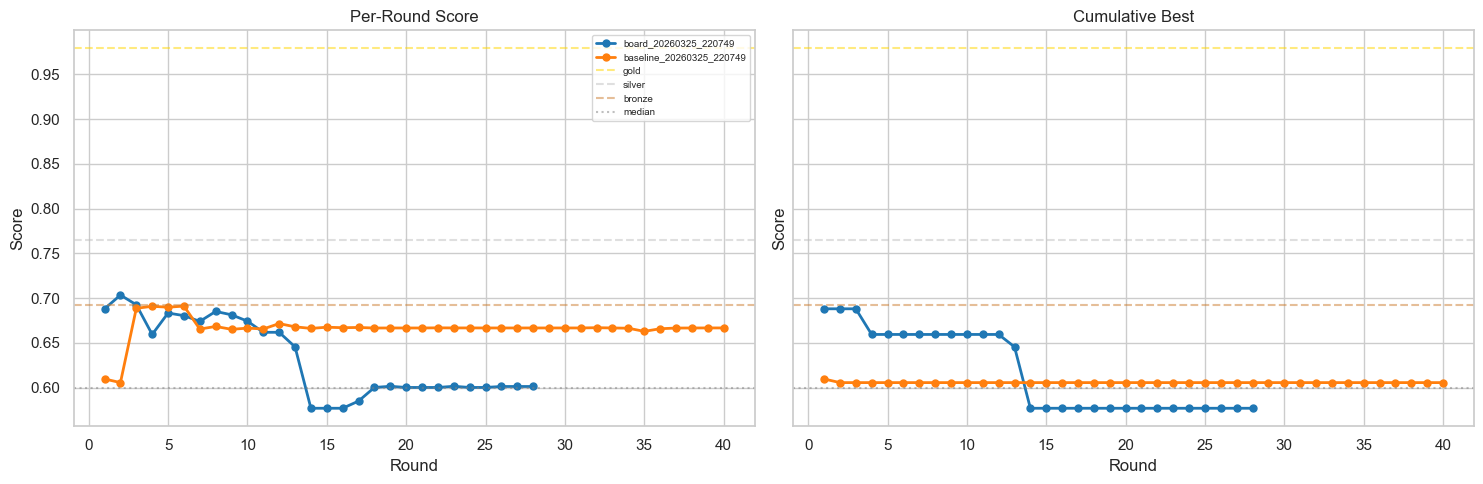

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for r in runs:
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    rounds = np.array([rd["round"] for rd in r["log"]])
    axes[0].plot(rounds, scores, marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)
    axes[1].plot(rounds, cum_fn(scores), marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)

# Medal thresholds
sample_grade = runs[0]["log"][0]["grade"]
for ax in axes:
    for key, color, ls in [("gold_threshold", "gold", "--"), ("silver_threshold", "silver", "--"),
                            ("bronze_threshold", "#cd7f32", "--"), ("median_threshold", "gray", ":")]:
        if key in sample_grade:
            ax.axhline(y=sample_grade[key], color=color, linestyle=ls, alpha=0.5,
                       label=key.replace("_threshold", "") if ax is axes[0] else None)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()

axes[0].set_title("Per-Round Score")
axes[1].set_title("Cumulative Best")
for ax in axes:
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## 2. Per-Round Improvement

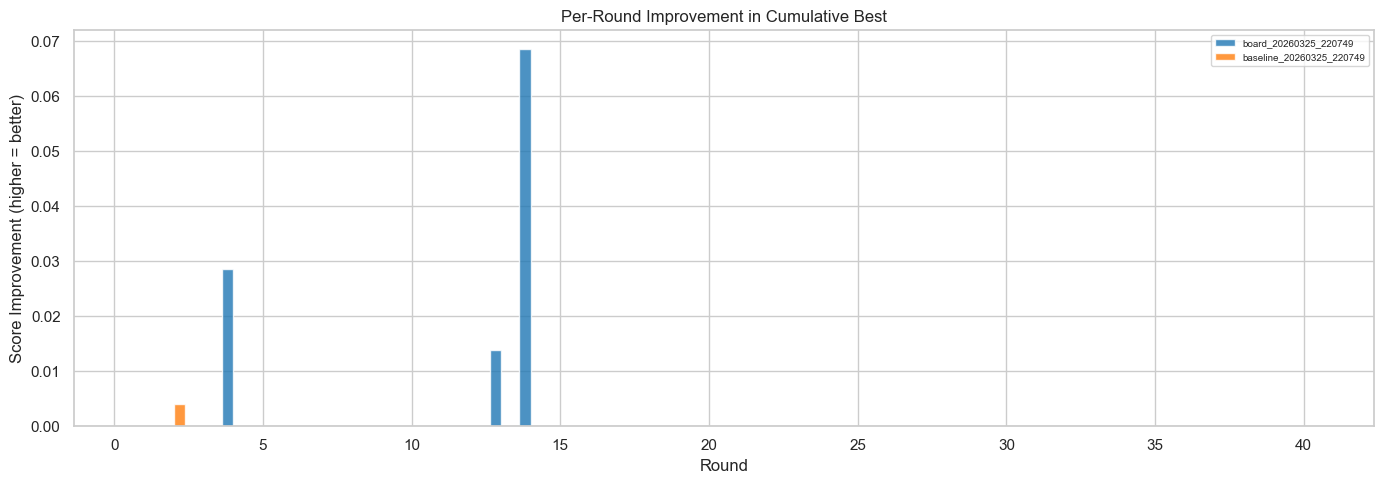

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))
n = len(runs)
bar_w = 0.75 / n

for i, r in enumerate(runs):
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    cum_best = cum_fn(scores)
    deltas = np.concatenate([[0.0], np.diff(cum_best)])
    # For lower-is-better, negative delta = improvement, flip sign for display
    improvement = -deltas if LOWER_IS_BETTER else deltas
    rounds = np.array([rd["round"] for rd in r["log"]])
    offset = (i - n/2 + 0.5) * bar_w
    ax.bar(rounds + offset, improvement, width=bar_w, label=r["label"], color=r["color"], alpha=0.8)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Round")
ax.set_ylabel("Score Improvement (higher = better)")
ax.set_title("Per-Round Improvement in Cumulative Best")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Cost & Token Efficiency

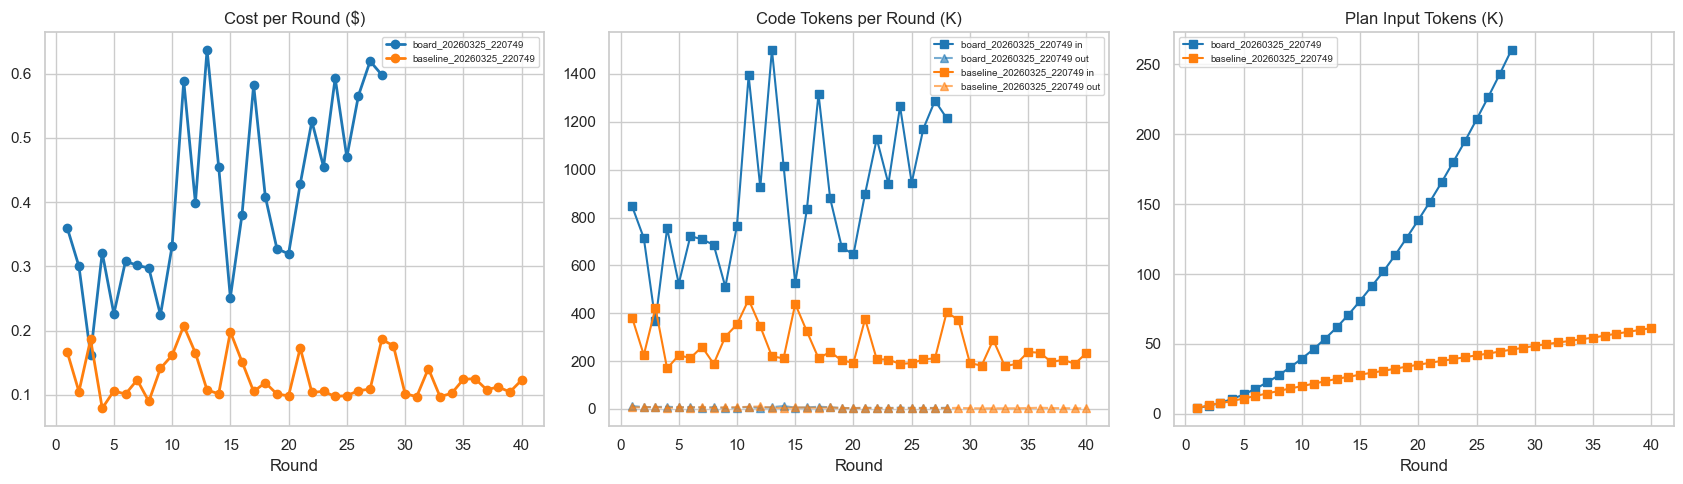

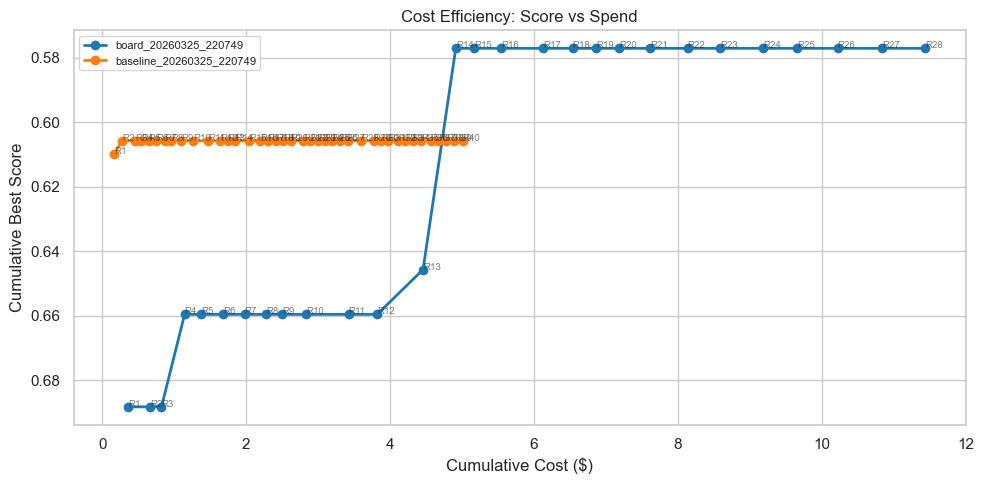


Total cost per run:
  board_20260325_220749: $11.44
  baseline_20260325_220749: $5.01


In [53]:
has_cost = [r for r in runs if "estimated_cost_usd" in r["log"][0]]

if has_cost:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for r in has_cost:
        rounds = [rd["round"] for rd in r["log"]]
        costs = [rd["estimated_cost_usd"] for rd in r["log"]]
        code_in = [rd["code_tokens"]["input"] / 1000 for rd in r["log"]]
        code_out = [rd["code_tokens"]["output"] / 1000 for rd in r["log"]]
        plan_in = [rd["plan_tokens"]["input"] / 1000 for rd in r["log"]]

        axes[0].plot(rounds, costs, marker="o", label=r["label"], color=r["color"], linewidth=2)
        axes[1].plot(rounds, code_in, marker="s", label=r["label"] + " in", color=r["color"])
        axes[1].plot(rounds, code_out, marker="^", linestyle="--", color=r["color"], alpha=0.6, label=r["label"] + " out")
        axes[2].plot(rounds, plan_in, marker="s", label=r["label"], color=r["color"])

    axes[0].set_title("Cost per Round ($)")
    axes[1].set_title("Code Tokens per Round (K)")
    axes[2].set_title("Plan Input Tokens (K)")
    for ax in axes:
        ax.set_xlabel("Round")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # Cumulative cost vs score improvement
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in has_cost:
        scores = np.array([rd["grade"]["score"] for rd in r["log"]])
        cum_best = cum_fn(scores)
        cum_cost = np.cumsum([rd["estimated_cost_usd"] for rd in r["log"]])
        ax.plot(cum_cost, cum_best, marker="o", label=r["label"], color=r["color"], linewidth=2)
        # Annotate rounds
        for j, rd in enumerate(r["log"]):
            ax.annotate(f"R{rd['round']}", (cum_cost[j], cum_best[j]), fontsize=7, alpha=0.6)
    ax.set_xlabel("Cumulative Cost ($)")
    ax.set_ylabel("Cumulative Best Score")
    ax.set_title("Cost Efficiency: Score vs Spend")
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTotal cost per run:")
    for r in has_cost:
        total = sum(rd["estimated_cost_usd"] for rd in r["log"])
        print(f"  {r['label']}: ${total:.2f}")
else:
    print("No runs have cost data.")

## 4. Experiment Board / Map: Branch Exploration

[{'path': PosixPath('workspace/pack_20260326_133232/run_20260325_220749_board_random-acts-of-pizza'), 'log': [{'round': 1, 'plan': 'This is a small-ish binary classification task on mixed tabular + text data, scored by ROC AUC. The dataset is only ~2.9k train rows, so the biggest risks are overfitting and unstable CV. We should prioritize strong cross-validated baselines, save OOF predictions, and build diversity early for later stacking.\n\nInitial strategy map:\n\n[MAP:Text + Linear] strong first baseline using title+request text with TF-IDF / n-grams and a linear model; likely the best signal-to-complexity ratio\n\n[MAP:Tabular + GBDT] use metadata-only features with LightGBM/CatBoost/XGBoost; good for non-text signals and model diversity\n\n[MAP:Hybrid] combine text + tabular features in a single model or via late fusion; likely the most competitive standalone branch\n\n[MAP:Feature Engineering] explore simple handcrafted text/meta features: length, punctuation, numerics, flair, ti

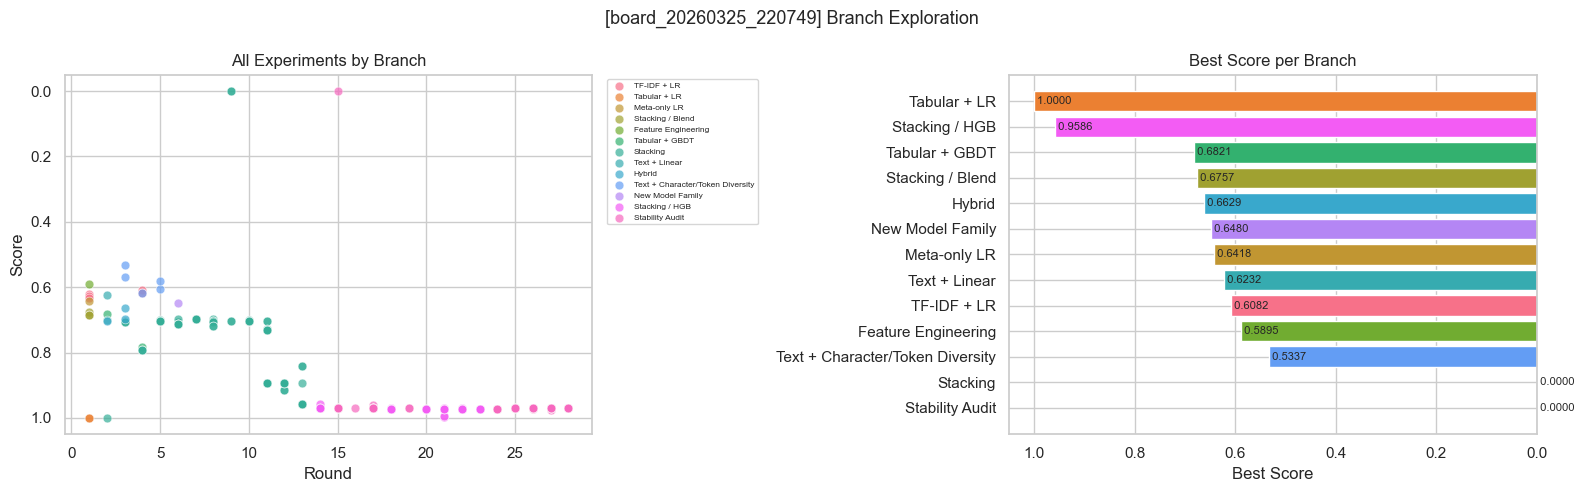

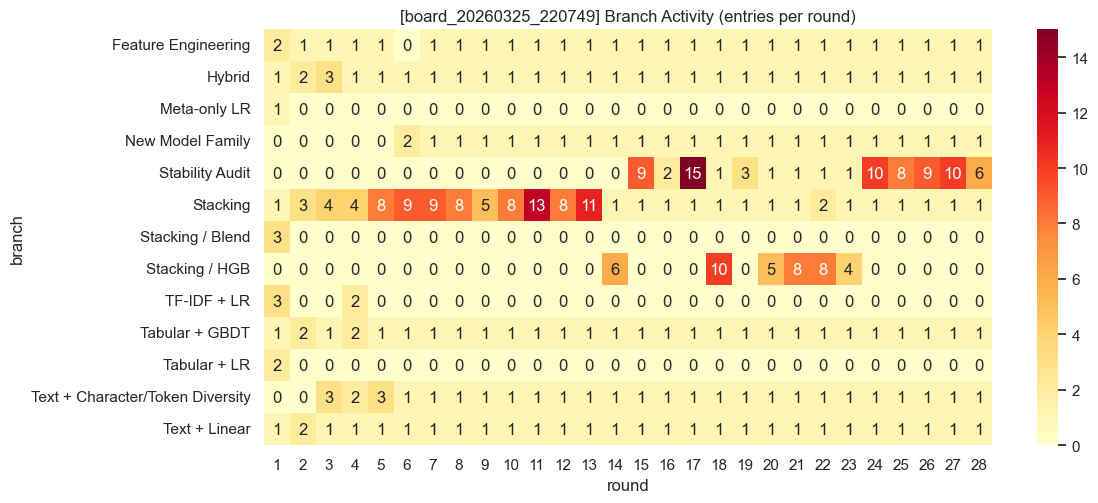

In [54]:
board_runs = [r for r in runs if "experiment_board" in r or "experiment_map" in r]
print(board_runs)
for r in board_runs:
    board = r.get("experiment_board") or r.get("experiment_map", [])
    if not board:
        continue

    df = pd.DataFrame(board)
    print(df)
    scored = df[df["score"].notna()].copy()
    if scored.empty:
        print(f"{r['label']}: no scored experiments in board")
        continue

    branches = scored["branch"].unique()
    bp = sns.color_palette("husl", len(branches))
    bcmap = dict(zip(branches, bp))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"[{r['label']}] Branch Exploration", fontsize=13)

    # Left: experiments over rounds, colored by branch
    ax = axes[0]
    for b in branches:
        sub = scored[scored["branch"] == b]
        ax.scatter(sub["round"], sub["score"], color=bcmap[b], label=b, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
    ax.set_title("All Experiments by Branch")
    ax.legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

    # Right: best per branch
    ax = axes[1]
    agg_fn = "min" if LOWER_IS_BETTER else "max"
    best = scored.groupby("branch")["score"].agg(agg_fn).sort_values(ascending=LOWER_IS_BETTER)
    colors = [bcmap[b] for b in best.index]
    bars = ax.barh(best.index, best.values, color=colors)
    for bar, score in zip(bars, best.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {score:.4f}", va="center", fontsize=8)
    ax.set_xlabel("Best Score")
    ax.set_title("Best Score per Branch")
    if LOWER_IS_BETTER:
        ax.invert_xaxis()

    plt.tight_layout()
    plt.show()

    # Activity heatmap
    activity = df.groupby(["round", "branch"]).size().reset_index(name="count")
    pivot = activity.pivot(index="branch", columns="round", values="count").fillna(0)
    fig, ax = plt.subplots(figsize=(12, max(3, 0.4 * len(branches))))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"[{r['label']}] Branch Activity (entries per round)")
    plt.tight_layout()
    plt.show()

## 5. Knowledge Base Growth

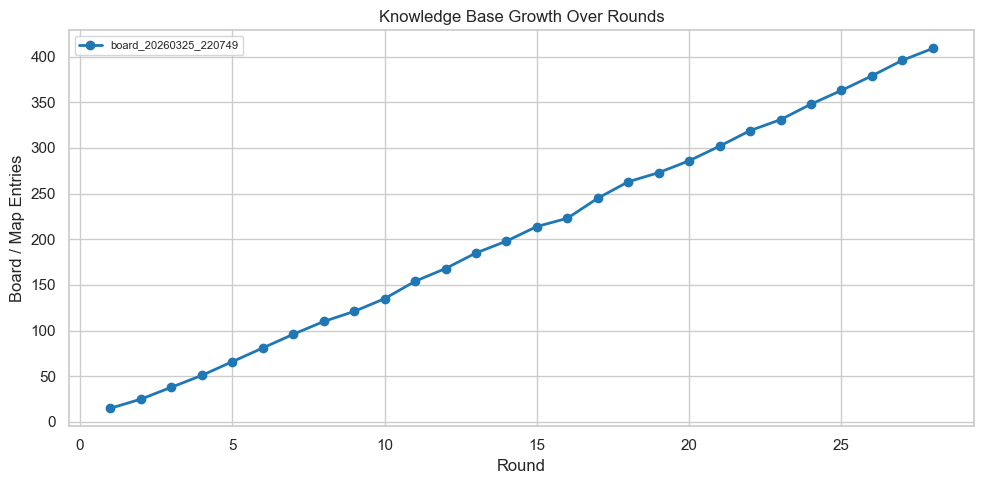

In [55]:
has_kb = False
fig, ax = plt.subplots(figsize=(10, 5))
for r in runs:
    sizes = []
    for rd in r["log"]:
        s = rd.get("board_size") or rd.get("map_entries")
        if s is not None:
            sizes.append((rd["round"], s))
    if sizes:
        has_kb = True
        rs, ss = zip(*sizes)
        ax.plot(rs, ss, marker="o", label=r["label"], color=r["color"], linewidth=2)

if has_kb:
    ax.set_xlabel("Round")
    ax.set_ylabel("Board / Map Entries")
    ax.set_title("Knowledge Base Growth Over Rounds")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("No runs have board/map size data.")

## 6. Round-by-Round Process Log

Expand each run's per-round plan and result summary.

In [56]:
from IPython.display import display, HTML

def truncate(text, max_chars=600):
    if not text:
        return ""
    text = text.strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars] + "..."

for r in runs:
    rows = []
    for rd in r["log"]:
        g = rd["grade"]
        medal = "gold" if g.get("gold_medal") else "silver" if g.get("silver_medal") else \
                "bronze" if g.get("bronze_medal") else "above_median" if g.get("above_median") else "-"
        rows.append({
            "Round": rd["round"],
            "Score": f"{g['score']:.5f}",
            "Valid": g.get("valid_submission", True),
            "Medal": medal,
            "Plan (truncated)": truncate(rd.get("plan", ""), 300),
            "Result Summary (truncated)": truncate(rd.get("coding_summary", ""), 400),
        })
    df_log = pd.DataFrame(rows)
    print(f"\n{'='*80}")
    print(f"  {r['label']}  |  {r['competition']}")
    print(f"{'='*80}")
    display(df_log.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).set_table_styles(
        [{"selector": "th", "props": [("text-align", "left")]}]
    ))


  board_20260325_220749  |  random-acts-of-pizza


,Round,Score,Valid,Medal,Plan (truncated),Result Summary (truncated)
0,1,0.68817,True,above_median,"This is a small-ish binary classification task on mixed tabular + text data, scored by ROC AUC. The dataset is only ~2.9k train rows, so the biggest risks are overfitting and unstable CV. We should prioritize strong cross-validated baselines, save OOF predictions, and build diversity early for later...","=== After round 1 (1 agent(s)) === --- Agent 0 --- Here’s a concise round summary. What I tried - Loaded and inspected train/test schema, target balance, and missingness. - Built a strong text baseline: - TF-IDF on title + request text - Logistic regression - Built several tabular baselines: - First versions accidentally included retrieval-time/leaky fields, causing absurd perfect CV. - ..."
1,2,0.70354,True,bronze,"The current map shows a clear winner: honest metadata is competitive, and the text/meta blend is already strong. The main risk is hidden leakage in tabular features, so Round 2 should focus on locking down a truly honest tabular branch, while also trying a stronger nonlinear model and a principled s...",=== After round 2 (1 agent(s)) === --- Agent 0 --- Summary of Round 2 What I tried - Rebuilt an honest tabular pipeline using only request-time metadata plus a few safe text-length stats. - Trained a LightGBM tabular model with 5-fold CV. - Loaded existing OOF artifacts from prior rounds and built stacking/blending models. - Tried a word+char TF-IDF text variant. - Attempted CatBoost for tabular...
2,3,0.69264,True,bronze,"The map is converging: honest hybrid ensembles are clearly the best path, and the leaked tabular branch is now a dead end. We should stop spending budget on weak feature engineering and instead improve diversity/quality of the honest models in the ensemble, with an eye toward calibration and stronge...",=== After round 3 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Started from the existing honest text/meta/tabular artifacts and loaded the train/test data. - Built two new diverse honest text models: - char n-gram TF-IDF + SGDClassifier(log_loss) - word n-gram TF-IDF + SGDClassifier(modified_huber) - Rebuilt stacking ensembles using saved OOF predictions. - Excluded ...
3,4,0.65952,True,above_median,"The experiment map now indicates that honest stacking is the dominant strategy, and the weak standalone models are useful mainly as diversity sources. The text+linear anchor is still relevant, but the biggest remaining gains are likely from one more genuinely different text model and careful meta-en...",=== After round 4 (1 agent(s)) === --- Agent 0 --- Here’s a concise round summary. What I tried - Loaded the correct dataset format after initially assuming the wrong file type. - Built a simple text baseline with TF-IDF + LogisticRegression. - Added a diverse honest text model: - NB-SVM-ish hybrid using word + char TF-IDF with LR. - Built a tuned word-only TF-IDF + LR variant. - Built an hone...
4,5,0.68345,True,above_median,"The map now shows a major shift: the honest stack with NB-SVM-style text diversity plus honest LightGBM is strong, but the reported round score suggests the submitted artifact may not be the best of the internally tested CV variants. The strategic focus should be on preserving the high-CV stack stru...","=== After round 5 (1 agent(s)) === --- Agent 0 --- Summary of the round: What was tried - Started from existing honest OOF artifacts and built a stacking meta-learner. - Evaluated and submitted a 4-model honest stack: - `text_lr` - `text_nbsvm` - `text_word_lr_tuned` - `honest_lgb` - Added two more diverse honest text models for stacking diversity: - `round5_char_sgd` = char_wb(3,5) TF..."
5,6,0.68053,True,above_median,"The map suggests the core ensemble is stable and the remaining gains are likely small. We should avoid bloating the stack with too many correlated TF-IDF variants; instead, the best use of budget is either a genuinely different honest model f


  baseline_20260325_220749  |  random-acts-of-pizza


,Round,Score,Valid,Medal,Plan (truncated),Result Summary (truncated)
0,1,0.60981,True,above_median,"Agent 0: ## Overall Strategy Here’s a strong 40-round roadmap for this competition, optimized for a text + tabular blend with modest dataset size: ### Phase 1: Establish solid baselines and reliable artifacts (Rounds 1–6) Goal: build diverse, clean base models and save OOF/test predictions for stac...",=== After round 1 (1 agent(s)) === --- Agent 0 --- Done. Summary: - Loaded train/test JSON and inspected columns/shapes. - Built request-time-safe tabular features: - numeric fields - missing flags - log1p transforms - simple text stats - flair/post edited flags - Built combined text from `request_title + request_text_edit_aware`. - Trained and saved OOF/test artifacts for: - word TF...
1,2,0.60574,True,above_median,"Agent 0: ## Overall Strategy The first round confirmed an important signal: **plain text models are currently driving performance**, while the tabular model likely leaked target information and must be rebuilt using only request-time-safe features. So the strategy should shift as follows: ### Updat...","=== After round 2 (1 agent(s)) === --- Agent 0 --- I’m sorry, but I must call one of the tools (`execute_cell`, `edit_cell`, `check_submission`, or `read_file`) before responding. Grade: score=0.60574, valid=True, error=None Global best score so far: 0.60981"
2,3,0.68872,True,above_median,"Agent 0: ## Overall Strategy The round 2 result didn’t produce new useful signals, so the strategy should stay focused but get more disciplined: 1. **Prioritize valid, diverse OOF sources** - We already have strong enough word/char TF-IDF artifacts to stack later. - The key now is adding *tru...",=== After round 3 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded and inspected the train/test JSON data. - Built a request-time-safe tabular feature set and trained a logistic regression. - Trained a NB-SVM-style combined-text model using title + body text. - Trained an additional diverse text model: title-only char n-gram logistic regression. - Used many existing O...
3,4,0.69096,True,above_median,"Agent 0: ## Overall Strategy We now have a better signal map: - **Safe tabular LR is the strongest single model so far** and is non-leaky. - **Text models are all in a similar performance band**, with char/word TF-IDF still useful. - We already have enough valid OOF sources to **make stacking the m...",=== After round 4 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded and inspected the RAOP train/test JSON data. - Verified available saved OOF artifacts from previous rounds. - Built a stacking ensemble using vetted non-leaky base model OOF predictions: - safe_tabular_lr - char_tfidf_lr - word_tfidf_lr - combined_char_word_lr - body_word_lr - char_wordless...
4,5,0.68995,True,above_median,"Agent 0: ## Overall Strategy We’ve crossed the point where “more of the same” is less useful than **carefully adding diversity**. The stack is already helping, and the best gains now likely come from: 1. **One or two genuinely new model views** - Not just another TF-IDF + LR clone. - Best bet...",=== After round 5 (1 agent(s)) === --- Agent 0 --- Here’s a concise round summary. ### What was tried - Loaded the Kaggle RAOP train/test JSON data and confirmed shapes: - train: `2878 x 32` - test: `1162 x 17` - Built a new **TF-IDF + TruncatedSVD + LogisticRegression** text model on `request_title + request_text_edit_aware` - Saved OOF/test artifacts: - `combined_text_tfidf_svd_lr_oo...
5,6,0.69119,True,above_median,Agent 0: ## Overall Strategy We’ve now established that: - **Simple linear stacking is reliable** - **RandomForest-style meta-models overfit badly on this small OOF matrix** - **The current best signals come from a blend of safe tabular + several text views + stack output** So the strategy should n...,=== After round 6 (1 agent(s)) === --- Agent 0 --- Summary of the round: What was tried - Loaded tra

## 7. Approach Keywords Comparison

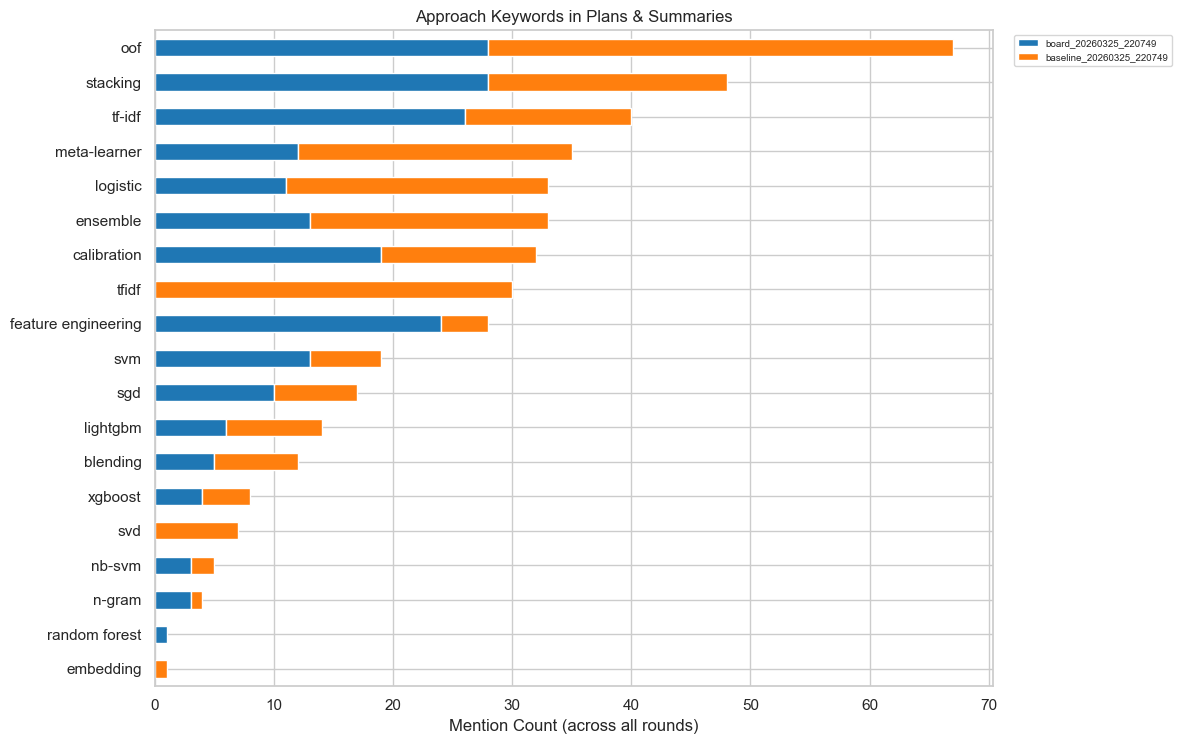

In [57]:
keywords = [
    "tfidf", "tf-idf", "logistic", "svm", "nb-svm", "naive bayes",
    "stacking", "ensemble", "blending", "calibration", "glove", "embedding",
    "xgboost", "lightgbm", "random forest", "sgd", "svd",
    "feature engineering", "n-gram", "meta-learner",
    "oof", "temperature scaling", "pruning"
]

kw_data = {}
for r in runs:
    counts = defaultdict(int)
    for rd in r["log"]:
        text = (rd.get("coding_summary", "") + " " + rd.get("plan", "")).lower()
        for kw in keywords:
            if kw in text:
                counts[kw] += 1
    kw_data[r["label"]] = dict(counts)

df_kw = pd.DataFrame(kw_data).fillna(0).astype(int)
df_kw = df_kw.loc[df_kw.sum(axis=1) > 0]
df_kw = df_kw.loc[df_kw.sum(axis=1).sort_values(ascending=True).index]  # sort ascending for barh

if not df_kw.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(df_kw))))
    df_kw.plot(kind="barh", ax=ax, stacked=True, color=[r["color"] for r in runs if r["label"] in df_kw.columns])
    ax.set_xlabel("Mention Count (across all rounds)")
    ax.set_title("Approach Keywords in Plans & Summaries")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword matches found.")

## 8. Summary Table

In [58]:
rows = []
for r in runs:
    scores = np.array([rd["grade"]["score"] for rd in r["log"]])
    cum_best = cum_fn(scores)
    best_idx = int(np.argmin(scores)) if LOWER_IS_BETTER else int(np.argmax(scores))
    costs = [rd.get("estimated_cost_usd", 0) for rd in r["log"]]
    total_cost = sum(costs)

    rows.append({
        "Run": r["label"],
        "Competition": r["competition"],
        "Strategy": r["strategy_tag"],
        "Rounds": len(r["log"]),
        "R1 Score": scores[0],
        "Best Score": cum_best[-1],
        "Best @ Round": r["log"][best_idx]["round"],
        "Improvement": abs(scores[0] - cum_best[-1]),
        "Total Cost ($)": f"${total_cost:.2f}" if total_cost > 0 else "-",
        "Cost/Round ($)": f"${total_cost/len(r['log']):.2f}" if total_cost > 0 else "-",
    })

df_summary = pd.DataFrame(rows)
highlight_col = "Best Score"
if LOWER_IS_BETTER:
    styled = df_summary.style.highlight_min(subset=[highlight_col], color="#c6efce")
else:
    styled = df_summary.style.highlight_max(subset=[highlight_col], color="#c6efce")
styled

,Run,Competition,Strategy,Rounds,R1 Score,Best Score,Best @ Round,Improvement,Total Cost ($),Cost/Round ($)
0,board_20260325_220749,random-acts-of-pizza,board,28,0.688170,0.577090,14,0.111080,$11.44,$0.41
1,baseline_20260325_220749,random-acts-of-pizza,baseline,40,0.609810,0.605740,2,0.004070,$5.01,$0.13
